In [1]:
pip install dagshub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import dagshub
import mlflow
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import numpy as np
import joblib, os
from sklearn.utils import class_weight
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [15]:
df = pd.read_csv("../data/rain_dataset.csv").dropna(subset=["rain_label"])
df.describe()

,lat,lon,temp_c,humidity,precipitation_mm,wind_speed,pressure,hour,day,month,temp_rolling_mean,humidity_rolling_mean,precip_rolling_sum,wind_rolling_mean,rain_next_hour,rain_label
count,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.00000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78912.000000,78909.000000,78912.000000
mean,14.985354,-16.127482,27.555796,51.388940,0.060325,12.292882,1011.623372,11.50000,15.732664,6.521898,27.555743,51.388212,0.361953,12.292834,0.060328,0.031326
std,1.134025,0.555957,5.120990,27.878398,0.519937,5.199194,2.112629,6.92223,8.801426,3.449008,4.655999,26.930578,1.919445,4.724643,0.519947,0.174198
min,13.743409,-16.911621,13.700000,3.000000,0.000000,0.000000,1002.300000,0.00000,1.000000,1.000000,14.683333,3.000000,0.000000,0.733333,0.000000,0.000000
25%,13.743409,-16.911621,24.100000,25.000000,0.000000,8.500000,1010.300000,5.75000,8.000000,4.000000,24.433333,26.500000,0.000000,8.750000,0.000000,0.000000
50%,14.727592,-15.785126,26.700000,50.000000,0.000000,12.000000,1011.700000,11.50000,16.000000,7.000000,26.966667,50.333333,0.000000,11.883333,0.000000,0.000000
75%,16.485060,-15.685699,31.000000,77.000000,0.000000,15.800000,1013.100000,17.25000,23.000000,10.000000,30.650000,75.833333,0.000000,15.466667,0.000000,0.000000
max,16.485060,-15.685699,46.200000,100.000000,33.700000,34.900000,1021.300000,23.00000,31.000000,12.000000,45.383333,99.166667,58.700000,33.083333,33.700000,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78912 entries, 0 to 78911
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   lat                    78912 non-null  float64
 1   lon                    78912 non-null  float64
 2   observation_time       78912 non-null  object 
 3   temp_c                 78912 non-null  float64
 4   humidity               78912 non-null  float64
 5   precipitation_mm       78912 non-null  float64
 6   wind_speed             78912 non-null  float64
 7   pressure               78912 non-null  float64
 8   hour                   78912 non-null  int64  
 9   day                    78912 non-null  int64  
 10  month                  78912 non-null  int64  
 11  temp_rolling_mean      78912 non-null  float64
 12  humidity_rolling_mean  78912 non-null  float64
 13  precip_rolling_sum     78912 non-null  float64
 14  wind_rolling_mean      78912 non-null  float64
 15  ra

Initialized MLflow to track repo "IbrahimFaye/weather-agri"

Repository IbrahimFaye/weather-agri initialized!

 Accuracy: 0.973 | F1: 0.582
 Résultats visibles sur DagsHub
🏃 View run vaunted-ram-942 at: https://dagshub.com/IbrahimFaye/weather-agri.mlflow/#/experiments/1/runs/e057bfe908df4fb3ad917e62a4ff3806
🧪 View experiment at: https://dagshub.com/IbrahimFaye/weather-agri.mlflow/#/experiments/1


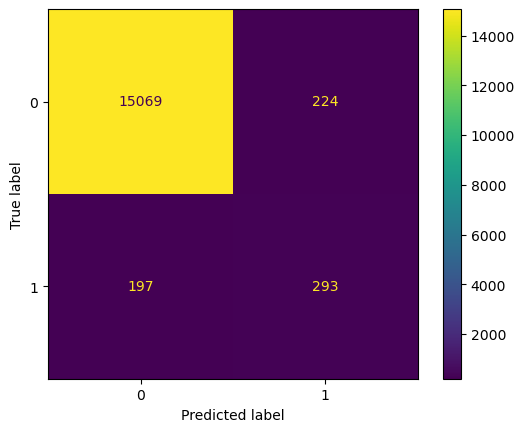

In [7]:
dagshub.init(repo_owner='IbrahimFaye', repo_name='weather-agri', mlflow=True)

def main():
    mlflow.set_experiment("rain_forecast")

    df = pd.read_csv("../data/rain_dataset.csv")
    df = df.dropna(subset=["rain_label"])
    df["rain_label"] = df["rain_label"].astype(int)

    exclude_cols = ["observation_time", "rain_label", "rain_next_hour"]
    df["sin_hour"] = np.sin(2 * np.pi * df["hour"]/24)
    df["cos_hour"] = np.cos(2 * np.pi * df["hour"]/24)
    df["sin_month"] = np.sin(2 * np.pi * df["month"]/12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"]/12)

    X = df.drop(columns=exclude_cols, errors="ignore").select_dtypes(include = ["number"])
    y = df["rain_label"]

    X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

    with mlflow.start_run():
        weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = {i: w for i, w in enumerate(weights)}
        model = XGBClassifier(scale_pos_weight=5, n_estimators=400 , max_depth=8, learning_rate=0.05)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        mlflow.log_params({"n_estimators": 200, "max_depth": 10, "random_state": 42})
        mlflow.log_metrics({"accuracy": acc, "f1_score": f1})
        
       
        os.makedirs("artifacts", exist_ok=True)
        joblib.dump(model, "artifacts/rain_model.pkl")
        mlflow.log_artifact("artifacts/rain_model.pkl", artifact_path="model")

        feature_importance = dict(zip(X.columns, np.round(model.feature_importances_, 4)))
        mlflow.log_dict(feature_importance, "feature_importance.json")

        ConfusionMatrixDisplay.from_predictions(y_test, preds)
        plt.savefig("artifacts/confusion_matrix.png")
        mlflow.log_artifact("artifacts/confusion_matrix.png", artifact_path="plots")
        
        print(f" Accuracy: {acc:.3f} | F1: {f1:.3f}")
        print(" Résultats visibles sur DagsHub")

if __name__ == "__main__":
    main()